# 🐼 Part 4: Matplotlib + Pandas – Visualizing DataFrames

In this notebook, we bridge the gap between data manipulation and data visualization. While manual lists are fine for small examples, professional workflows rely on **Pandas** to handle large datasets (like CSV files).

### 🎯 Objective
Learn how to extract insights from a structured dataset and transform those raw numbers into clear, categorized visualizations.

---

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 🧪 Step 1: The Power of the DataFrame

### Why Pandas?
In our previous notes, we manually created NumPy arrays. However, **Pandas** is the industry standard for:
* **Data Loading**: Easily reading CSV, Excel, or SQL data.
* **Cleaning**: Handling missing values or filtering specific categories.
* **Aggregation**: Using functions like `.value_counts()` to instantly summarize your data.

### 🛠️ Key Commands
* `pd.read_csv('file.csv')`: Loads your external data into a DataFrame.
* `df.head()`: Previews the first 5 rows to understand the structure.
* `df['Column'].value_counts()`: Counts occurrences of unique values—perfect for Bar and Pie charts!

In [ ]:
df = pd.read_csv('sampledata.csv')
print(df.head())
print(df['Type1'].value_counts())

## 🎨 Step 2: Advanced Categorical Plotting

This cell demonstrates how to handle categorical data when you have specific color requirements for different labels (e.g., matching Pokémon types to their iconic colors).


### 📖 Code Breakdown & New Concepts

#### 1. Data Aggregation
`typecounts = df['Type1'].value_counts()`
* This creates a **Series** where the Index is the Pokémon Type (Water, Fire, etc.) and the Values are the total counts.

#### 2. The Color Map (The Mapping Dictionary)
Instead of random colors, we define a dictionary where keys match our data labels. 

#### 3. List Comprehension for Colors
`bar_colors = [color_map.get(x, '#868686') for x in typecounts.index]`
* **Why this is smart**: It ensures that the color order matches the `typecounts` order exactly.
* **`.get(x, '#868686')`**: This is a "fail-safe." If a type isn't in your dictionary, it defaults to a neutral grey instead of crashing your code.

#### 4. The `plt.bar()` Call
* `plt.bar(typecounts.index, typecounts.values, color=bar_colors)`
* **Note**: We pass the list to the `color` argument. We **do not** use `**color_map` here because `Water` is not a valid Matplotlib argument name.

#### 5. Layout Polish
* **`plt.xticks(rotation=45)`**: Necessary for categorical data so the labels don't overlap.
* **`plt.tight_layout()`**: Crucial for ensuring the labels aren't cut off at the bottom of the image.

---
### 🛠️ Customization Cheat Sheet
| Function | Argument | Purpose |
| :--- | :--- | :--- |
| `plt.bar` | `color` | Accepts a list of colors to style each bar individually. |
| `plt.xticks` | `rotation` | Angles the text (e.g., 45 or 90 degrees) for readability. |
| `plt.grid` | `axis='y'` | Often, showing only horizontal grid lines makes Bar charts look cleaner. |

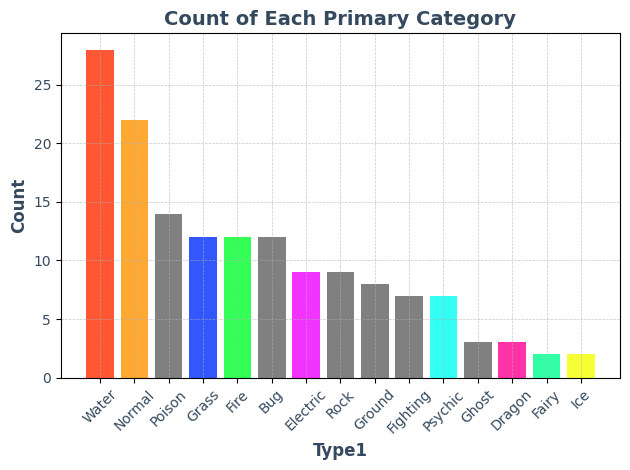

In [15]:
typecounts = df['Type1'].value_counts()
color_map = {
    'Water': '#FF5733', 'Fire': '#33FF57', 'Grass': '#3357FF', 
    'Electric': '#F333FF', 'Psychic': '#33FFF5', 'Ice': '#F5FF33', 
    'Dragon': '#FF33A8', 'Dark': '#A833FF', 'Fairy': '#33FFA8', 
    'Normal': '#FFA833'
}
bar_colors = [color_map.get(x, '#808080') for x in typecounts.index]
plt.bar(typecounts.index, typecounts.values, color=bar_colors)
plt.xlabel('Type1', fontsize=12, fontweight='bold', color='#34495E')
plt.ylabel('Count', fontsize=12, fontweight='bold', color='#34495E')
plt.title('Count of Each Primary Category', fontsize=14, fontweight='bold', color='#34495E')
plt.xticks(rotation=45, fontsize=10, color='#34495E')
plt.yticks(fontsize=10, color='#34495E')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()